In [1]:
from pathlib import Path 
import numpy as np

import matplotlib.pyplot as plt

def list_npy_files(folder):
    return [x for x in Path(folder).glob('**/**/*.npy')]

def shift_bounding_box(box, shift_x, shift_y):
    """
    Shift a bounding box by a specified number of pixels horizontally and vertically.

    Parameters:
    - box: array-like of shape (4,) representing [x_min, y_min, x_max, y_max] of the bounding box.
    - shift_x: int, the number of pixels to shift horizontally. Positive values shift right, negative values shift left.
    - shift_y: int, the number of pixels to shift vertically. Positive values shift down, negative values shift up.

    Returns:
    - shifted_box: np.ndarray of shape (4,) representing the shifted bounding box [x_min, y_min, x_max, y_max].
    """
    x_min, y_min, x_max, y_max = box
    shifted_box = np.array([x_min + shift_x, y_min + shift_y, x_max + shift_x, y_max + shift_y])
    return shifted_box

npy_files = list_npy_files('/Data_large/marine/PythonProjects/MMDET/studies/crops/B1')
npy_shapes = [np.load(x).shape for x in npy_files]
areas = [a*b for a,b in npy_shapes]

In [2]:
# Assuming 'areas' is your data array
areas = np.array(areas)

# Number of bins you want
num_bins = 5

# Calculate the bin edges using percentiles
bin_edges = np.percentile(areas, np.linspace(0, 100, num_bins + 1))

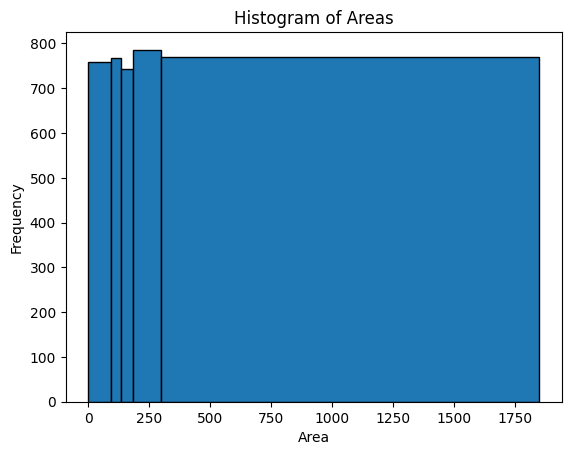

Bin 1: Start = 0.0, End = 95.0, Average = 37.58498023715415
Bin 2: Start = 95.0, End = 133.0, Average = 114.03776041666667
Bin 3: Start = 133.0, End = 182.0, Average = 154.71908602150538
Bin 4: Start = 182.0, End = 297.0, Average = 230.3091603053435
Bin 5: Start = 297.0, End = 1848.0, Average = 429.6614583333333


In [3]:
# Plot the histogram with custom bin edges
plt.hist(areas, bins=bin_edges, edgecolor='black')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.title('Histogram of Areas')
plt.show()

# Calculate the average value for each bin
bin_averages = []
for i in range(len(bin_edges) - 1):
    # Select elements in the current bin range
    bin_data = areas[(areas >= bin_edges[i]) & (areas < bin_edges[i + 1])]
    # Calculate the average of the current bin
    bin_avg = np.mean(bin_data) if len(bin_data) > 0 else np.nan
    bin_averages.append(bin_avg)
    print(f"Bin {i + 1}: Start = {bin_edges[i]}, End = {bin_edges[i + 1]}, Average = {bin_avg}")



Shift (1,0):
Average IoU: 0.837962462208615
Loss in IoU: 0.16203753779138497
------------------------------
Average IoU:
0.837962462208615
Loss in IoU:
0.16203753779138497
Shift (0,1):
Average IoU: 0.7845136174364986
Loss in IoU: 0.2154863825635014
------------------------------
Average IoU:
0.7845136174364986
Loss in IoU:
0.2154863825635014
Shift (1,1):
Average IoU: 0.6799191594107867
Loss in IoU: 0.32008084058921327
------------------------------
Average IoU:
0.6799191594107867
Loss in IoU:
0.32008084058921327


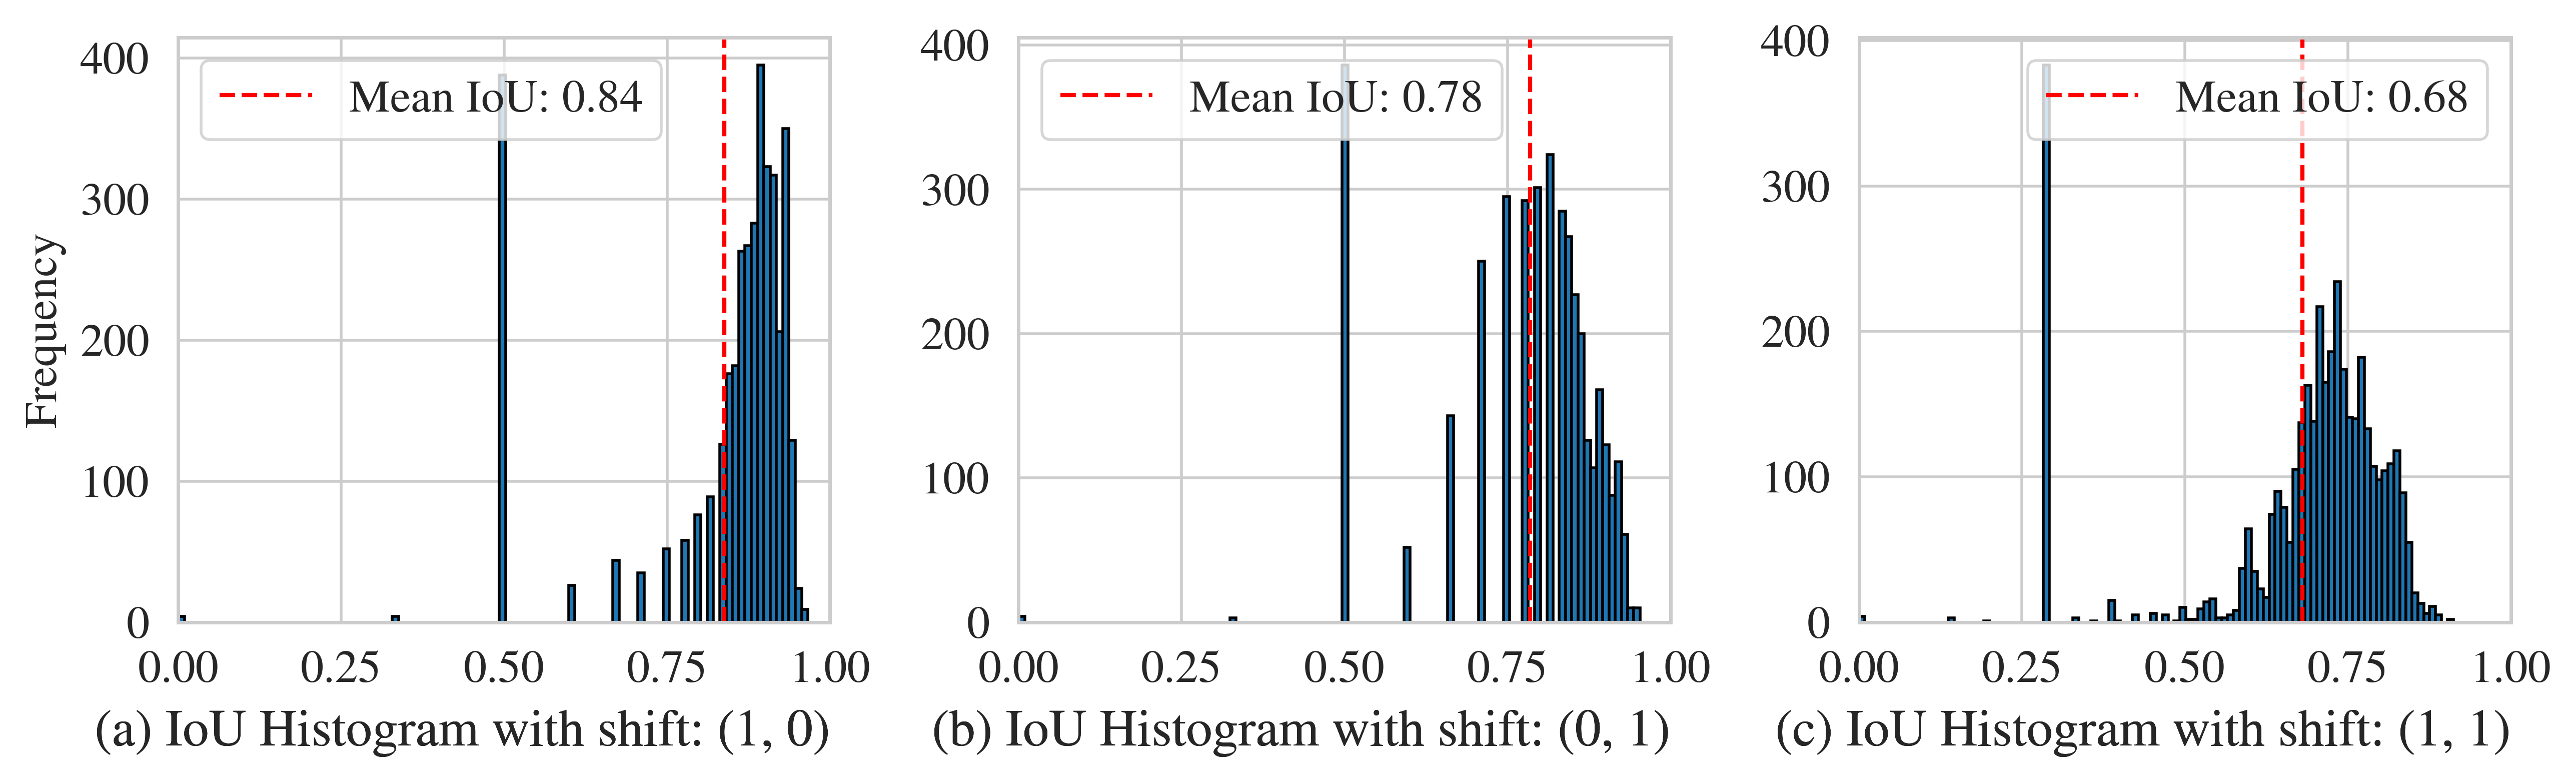

In [24]:
import numpy as np
from style import set_style 
import matplotlib.pyplot as plt

set_style(scale_factor=0.7, fontsize=19)

def calculate_iou(box1, box2):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes.
    
    Parameters:
    - box1: array-like of shape (4,) representing [x_min, y_min, x_max, y_max] for the first box
    - box2: array-like of shape (4,) representing [x_min, y_min, x_max, y_max] for the second box
    
    Returns:
    - iou: float representing the IoU between the two boxes
    """
    x_min1, y_min1, x_max1, y_max1 = box1
    x_min2, y_min2, x_max2, y_max2 = box2
    
    # Calculate the coordinates of the intersection rectangle
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)
    
    # Calculate the area of the intersection rectangle
    inter_area = max(0, x_max_inter - x_min_inter) * max(0, y_max_inter - y_min_inter)
    
    # Calculate the area of both bounding boxes
    box1_area = (x_max1 - x_min1) * (y_max1 - y_min1)
    box2_area = (x_max2 - x_min2) * (y_max2 - y_min2)
    
    # Calculate the union area
    union_area = box1_area + box2_area - inter_area
    
    # Calculate the IoU
    iou = inter_area / union_area if union_area != 0 else 0
    return iou

def compute_map_at_thresholds(gt_boxes, pred_boxes, iou_thresholds=[0.5, 0.75]):
    """
    Compute mAP, mAP_50, and mAP_75 for given ground truth and predicted bounding boxes.
    
    Parameters:
    - gt_boxes: array-like of shape (n_boxes, 4) representing the ground truth bounding boxes
    - pred_boxes: array-like of shape (n_boxes, 4) representing the predicted bounding boxes
    - iou_thresholds: list of IoU thresholds to compute mAP (default: [0.5, 0.75])
    
    Returns:
    - mAP_results: dict with keys 'mAP', 'mAP_50', 'mAP_75' and their corresponding values
    """
    assert len(gt_boxes) == len(pred_boxes), "Number of GT and predicted boxes must match."
    
    mAP_results = {}
    
    for threshold in iou_thresholds:
        tp = 0  # true positives
        fp = 0  # false positives
        fn = 0  # false negatives
        
        for gt_box, pred_box in zip(gt_boxes, pred_boxes):
            iou = calculate_iou(gt_box, pred_box)
            if iou >= threshold:
                tp += 1
            else:
                fp += 1
        
        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / len(gt_boxes) if len(gt_boxes) != 0 else 0
        
        mAP_results[f'mAP_{int(threshold * 100)}'] = precision
    
    mAP_results['mAP'] = np.mean(list(mAP_results.values()))
    
    return mAP_results

def create_bbox(x_min, y_min, height, width):
    """
    Creates a bounding box with the specified height and width, starting from the top-left corner (x_min, y_min).

    Parameters:
    -----------
    x_min : int or float
        The x-coordinate of the top-left corner of the bounding box.
    y_min : int or float
        The y-coordinate of the top-left corner of the bounding box.
    height : int or float
        The height of the bounding box.
    width : int or float
        The width of the bounding box.

    Returns:
    --------
    bbox : tuple
        A tuple representing the bounding box as (x_min, y_min, x_max, y_max), where (x_max, y_max) is the bottom-right corner.
    """
    x_max = x_min + width
    y_max = y_min + height
    return (x_min, y_min, x_max, y_max)

def compute_iou_at_thresholds(gt_boxes, pred_boxes):
    """
    Compute mAP, mAP_50, and mAP_75 for given ground truth and predicted bounding boxes.
    
    Parameters:
    - gt_boxes: array-like of shape (n_boxes, 4) representing the ground truth bounding boxes
    - pred_boxes: array-like of shape (n_boxes, 4) representing the predicted bounding boxes
    - iou_thresholds: list of IoU thresholds to compute mAP (default: [0.5, 0.75])
    
    Returns:
    - mAP_results: dict with keys 'mAP', 'mAP_50', 'mAP_75' and their corresponding values
    """
    assert len(gt_boxes) == len(pred_boxes), "Number of GT and predicted boxes must match."
    
    IoUs = []
    
    tp = 0  # true positives
    fp = 0  # false positives
    fn = 0  # false negatives
    
    for gt_box, pred_box in zip(gt_boxes, pred_boxes):
        iou = calculate_iou(gt_box, pred_box)
        IoUs.append(iou)
    
    # precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    # recall = tp / len(gt_boxes) if len(gt_boxes) != 0 else 0
    
    return IoUs

def comput_iou_result_pershift(shift_x, shift_y):
    # Example usage
    x_min, y_min = 100, 100
    gt_boxes = np.array([create_bbox(x_min, y_min, height, width) for height, width in npy_shapes])  # Ground truth bounding box (19x9)
    pred_boxes_shifted = np.array([shift_bounding_box(box, shift_x, shift_y) for box in gt_boxes])  # Shifted bounding box by 1 pixel right and bottom

    # map_results = compute_map_at_thresholds(gt_boxes, pred_boxes_shifted)
    iou_results = compute_iou_at_thresholds(gt_boxes, pred_boxes_shifted)
    return iou_results

fig, axes = plt.subplots(ncols=3,)

# Iterate over the axes and shift configurations
for ax, (sX, sY) in zip(axes, [(1, 0), (0, 1), (1, 1)]):
    # Compute IoU results for the given shift
    iou_results = comput_iou_result_pershift(shift_x=sX, shift_y=sY)
    
    # Plot histogram of IoU results
    ax.hist(iou_results, bins=100, edgecolor='black')
    # ax.set_title(f'IoU with px error: (H = {sX}px, V = {sY}px)')
    ax.set_xlim([0,1])
    # ax.set_xlabel('IoU')
    
    # Calculate and plot the mean IoU value
    mean_iou = np.mean(iou_results)
    ax.axvline(mean_iou, color='red', linestyle='--', label=f'Mean IoU: {mean_iou:.2f}')
    ax.legend()
    # Print IoU statistics
    print(f'Shift ({sX},{sY}):')
    print('Average IoU:', np.mean(iou_results))
    print('Loss in IoU:', 1 - np.mean(iou_results))
    print('-' * 30)

    print('Average IoU:')
    print(np.mean(iou_results))
    print('Loss in IoU:')
    print(1 - np.mean(iou_results))
    # Add labels to the subplots
    labels = ['IoU Histogram with shift: (1, 0)', 'IoU Histogram with shift: (0, 1)', 'IoU Histogram with shift: (1, 1)']
    for i, (sX, sY) in enumerate([(1, 0), (0, 1), (1, 1)]):
        axes[i].text(1, -0.15, f'({chr(97+i)}) {labels[i]}', transform=axes[i].transAxes, fontsize=15, fontweight='normal', va='top', ha='right')
        axes[i].set_xlabel('')

    axes[0].set_ylabel('Frequency')
    # Add a common title for the entire figure
    # fig.suptitle('IoU Histograms with Shift Configurations', fontsize=14, fontweight='bold')

    # Adjust the spacing between subplots
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    
plt.savefig('/Data_large/marine/PythonProjects/MMDET/plots/1px_error.png')